In [167]:
import pandas as pd
from openpyxl import load_workbook
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


In [168]:
butyrate_data = pd.read_excel("data/butyrate_pick.xlsx", index_col=0)
food_data = pd.read_csv('data/Summarized_Food_Categories_Only.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

In [169]:
# Selecting the first and ninth columns by index, assuming 'ID' is the first column
participants_reduced = participants_data.iloc[:, [7]]
participants_reduced

,FREG5_Ethnic_Group
Participant_ID,
10457,C
10924,M
7036,M
10529,C
10420,I
...,...
10147,C
10546,M
10058,I


In [170]:
merged_data = pd.merge(participants_reduced, food_data, on='Participant_ID')
merged_data

,FREG5_Ethnic_Group,Fish,Crustacean,Mollusk,Seafood_dishes,Poultry,Red_meat,Meat_dishes,Processed_meat,Dairy,Cruciferous_vegetables,Legumes,Mushroom,Fruits,Wholegrain,Chapati,Noodle_dishes,Deep_fried,Coffee,Tea
Participant_ID,,,,,,,,,,,,,,,,,,,,
10457,C,0.78,0.14,0.08,0.94,0.86,0.42,0.36,0.17,1.22,0.67,0.10,0.24,1.00,0.0600,0.00,0.680,0.17,1.00,0.36
10924,M,0.27,0.08,0.00,0.24,0.24,0.32,0.16,0.16,1.30,0.02,0.09,0.00,0.22,0.3000,0.00,0.640,0.19,1.00,1.00
7036,M,0.14,0.36,0.00,0.50,0.72,0.16,0.16,0.00,0.00,0.35,0.43,0.07,0.08,0.1475,0.00,1.000,0.03,2.50,0.00
10529,C,0.80,0.44,0.16,1.32,1.42,0.52,0.44,0.00,0.87,0.94,0.20,0.10,2.50,1.0700,0.00,0.880,0.00,1.00,0.14
10420,I,0.00,0.00,0.00,0.00,0.00,0.08,0.00,0.00,1.80,0.12,0.15,0.00,2.00,0.5000,1.00,0.165,0.14,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10147,C,0.43,0.14,0.00,0.30,1.44,0.52,0.16,1.08,0.44,0.18,0.01,0.01,0.03,0.8300,0.00,4.540,0.47,2.50,0.00
10546,M,0.28,0.00,0.00,0.28,0.72,0.22,0.22,0.00,1.36,0.49,0.14,0.04,0.36,2.4400,0.00,0.560,0.03,1.00,0.00
10058,I,1.23,0.11,0.03,1.21,1.78,0.00,0.00,0.36,0.80,0.09,0.84,0.12,1.00,0.7200,0.08,1.980,0.11,0.36,1.00


In [171]:
filtered_data = merged_data[merged_data['FREG5_Ethnic_Group'] != 'O']
grouped_data = filtered_data.groupby('FREG5_Ethnic_Group').mean()
#correlation_matrix = grouped_data.corr()
#correlation_matrix

In [172]:

#plt.figure(figsize=(10, 8))
#sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
#plt.title('Correlation Heatmap of Food Intake by Ethnic Group')
#plt.show()
grouped_data2 = grouped_data.clip(lower=0.2, upper=1)
grouped_data2

,Fish,Crustacean,Mollusk,Seafood_dishes,Poultry,Red_meat,Meat_dishes,Processed_meat,Dairy,Cruciferous_vegetables,Legumes,Mushroom,Fruits,Wholegrain,Chapati,Noodle_dishes,Deep_fried,Coffee,Tea
FREG5_Ethnic_Group,,,,,,,,,,,,,,,,,,,
C,0.373028,0.2,0.2,0.417048,0.883232,0.413155,0.322595,0.200000,0.688066,0.414020,0.324631,0.2,0.790789,0.634453,0.2,0.962163,0.200000,0.912621,0.493384
I,0.446374,0.2,0.2,0.489451,0.955934,0.388571,0.285934,0.265495,0.651538,0.416374,0.312857,0.2,1.000000,0.759313,0.2,1.000000,0.241319,0.941868,0.535934
M,0.402653,0.2,0.2,0.460000,0.579184,0.431224,0.350816,0.200000,0.790816,0.377143,0.307959,0.2,0.948163,0.776735,0.2,0.880102,0.200000,1.000000,0.364082


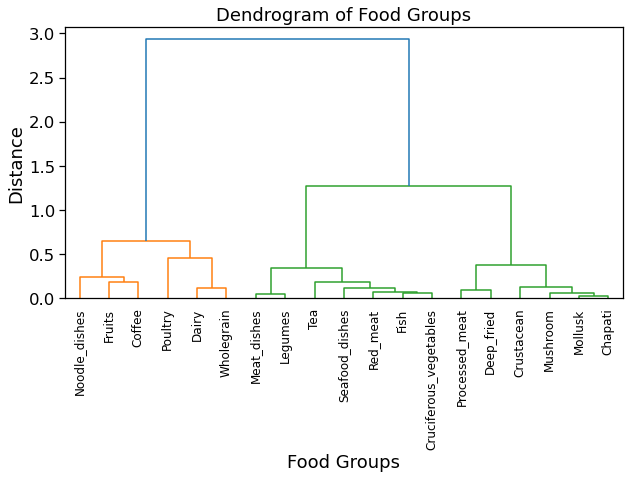

In [173]:
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the linkage matrix for clustering
Z = linkage(grouped_data.transpose(), 'ward')  # 'ward' is one method of clustering

# Plotting a dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=grouped_data2.columns, leaf_rotation=90)
plt.title('Dendrogram of Food Groups')
plt.xlabel('Food Groups')
plt.ylabel('Distance')
plt.show()



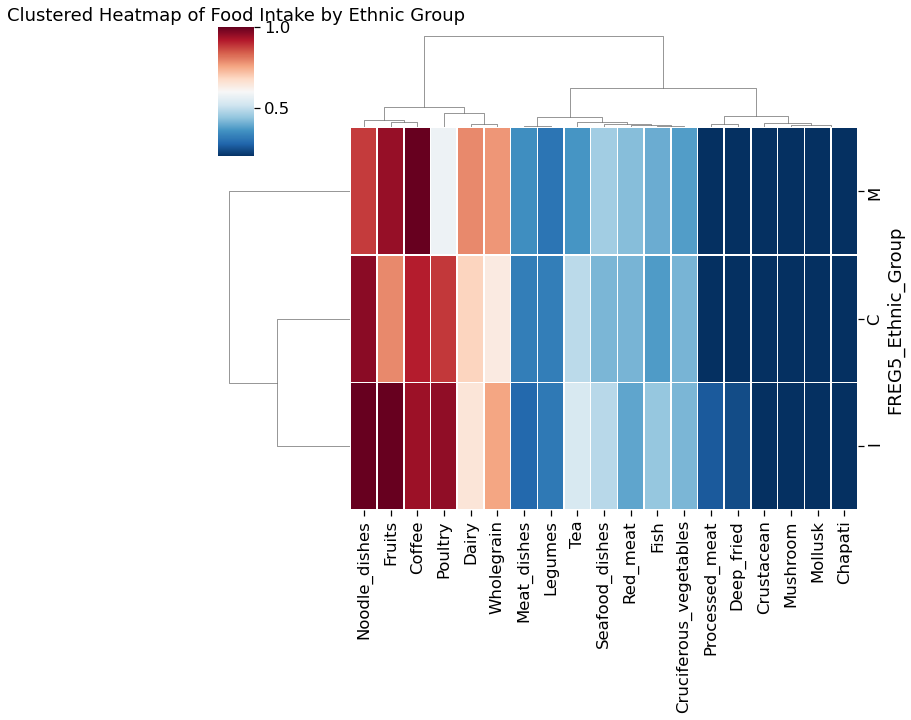

In [174]:
# Creating the clustered heatmap
sns.clustermap(grouped_data2, cmap='RdBu_r', fmt=".2f", linewidths=.5, method='ward', col_linkage=Z)
plt.title('Clustered Heatmap of Food Intake by Ethnic Group')
plt.show()


In [175]:
# z score

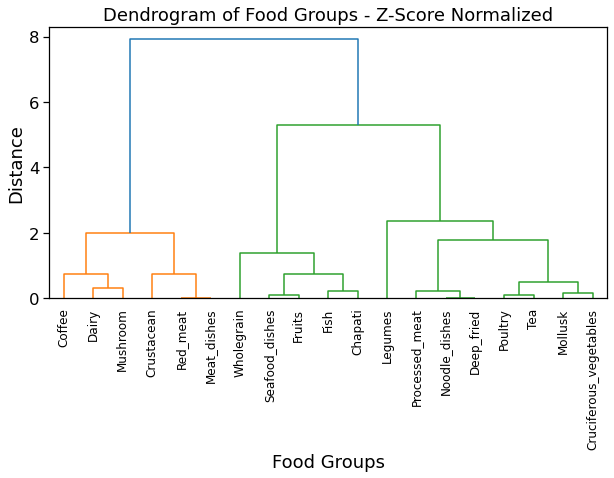

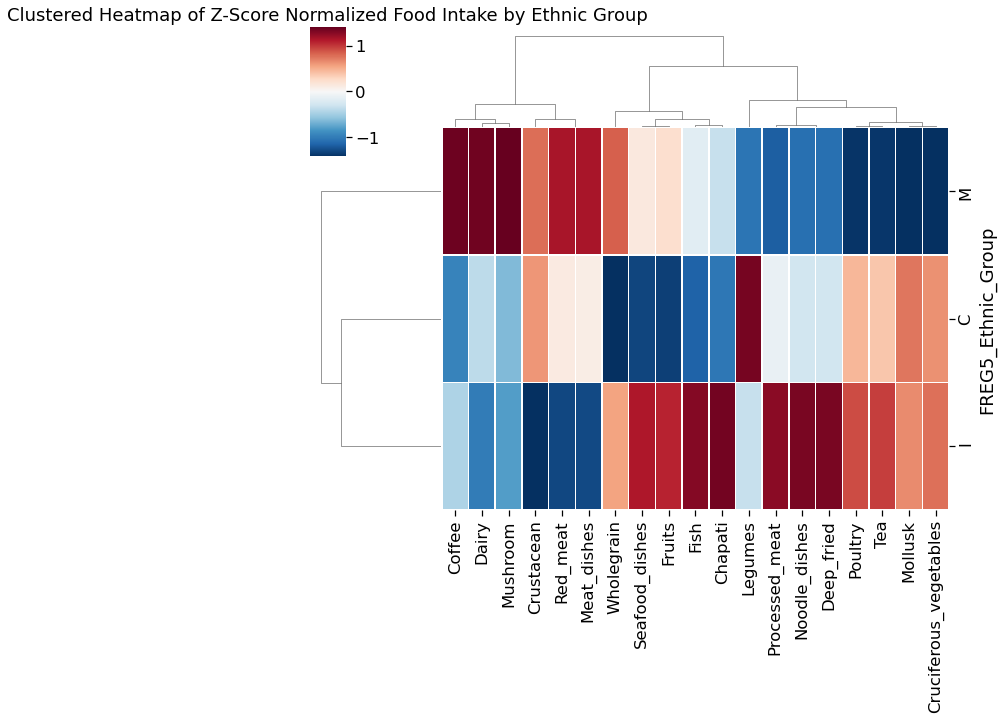

In [176]:
from scipy.stats import zscore
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt

# Apply Z-score normalization
normalized_data = grouped_data.apply(zscore)
#normalized_data2 = normalized_data.clip(lower=-1, upper=1)


# Clustering
Z = linkage(normalized_data.transpose(), 'ward')

# Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=normalized_data.columns, leaf_rotation=90)
plt.title('Dendrogram of Food Groups - Z-Score Normalized')
plt.xlabel('Food Groups')
plt.ylabel('Distance')
plt.show()

# Clustered heatmap
sns.clustermap(normalized_data, cmap='RdBu_r', fmt=".2f", linewidths=.5, method='ward', col_linkage=Z)
plt.title('Clustered Heatmap of Z-Score Normalized Food Intake by Ethnic Group')
plt.show()


In [177]:
# logtransform

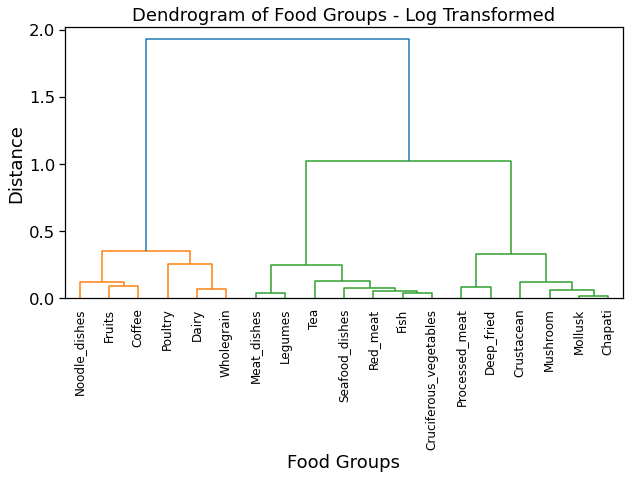

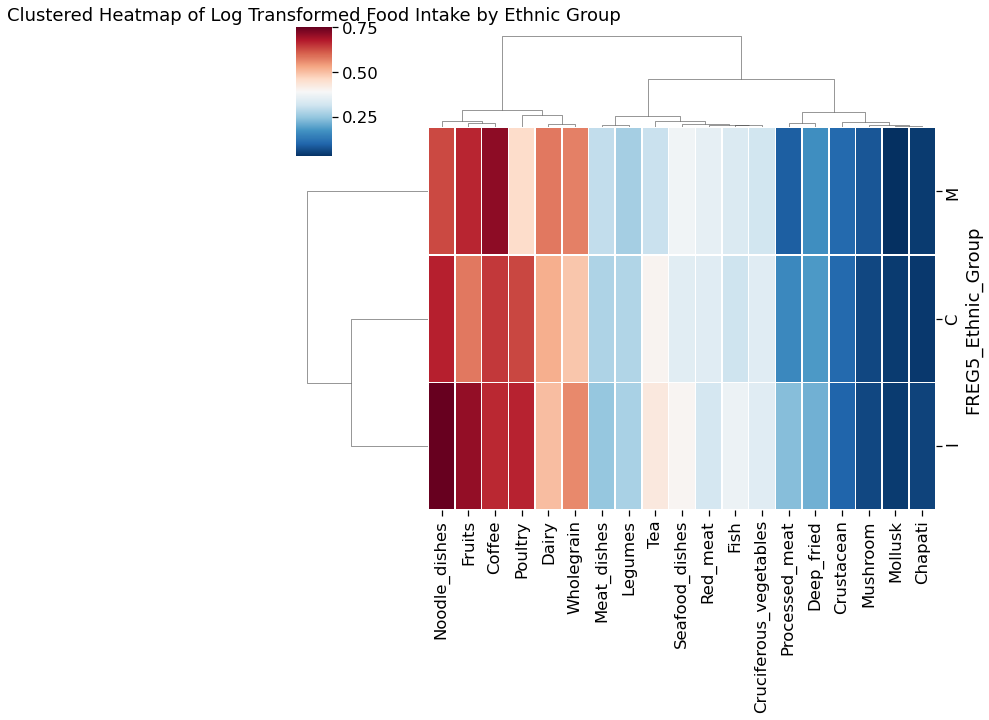

In [178]:
import numpy as np

# Apply logarithmic transformation, adding 1 to avoid log(0)
log_transformed_data = np.log1p(grouped_data)

# Clustering and heatmap visualization
Z = linkage(log_transformed_data.transpose(), 'ward')

# Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=log_transformed_data.columns, leaf_rotation=90)
plt.title('Dendrogram of Food Groups - Log Transformed')
plt.xlabel('Food Groups')
plt.ylabel('Distance')
plt.show()

# Clustered heatmap
sns.clustermap(log_transformed_data, cmap='RdBu_r', fmt=".2f", linewidths=.5, method='ward', col_linkage=Z)
plt.title('Clustered Heatmap of Log Transformed Food Intake by Ethnic Group')
plt.show()


In [179]:
#min-max

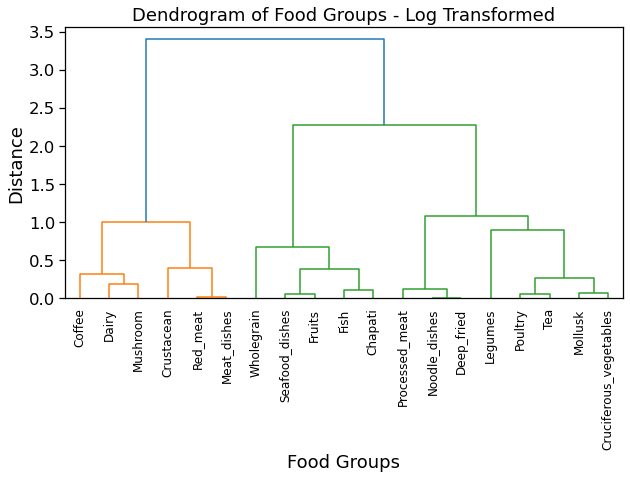

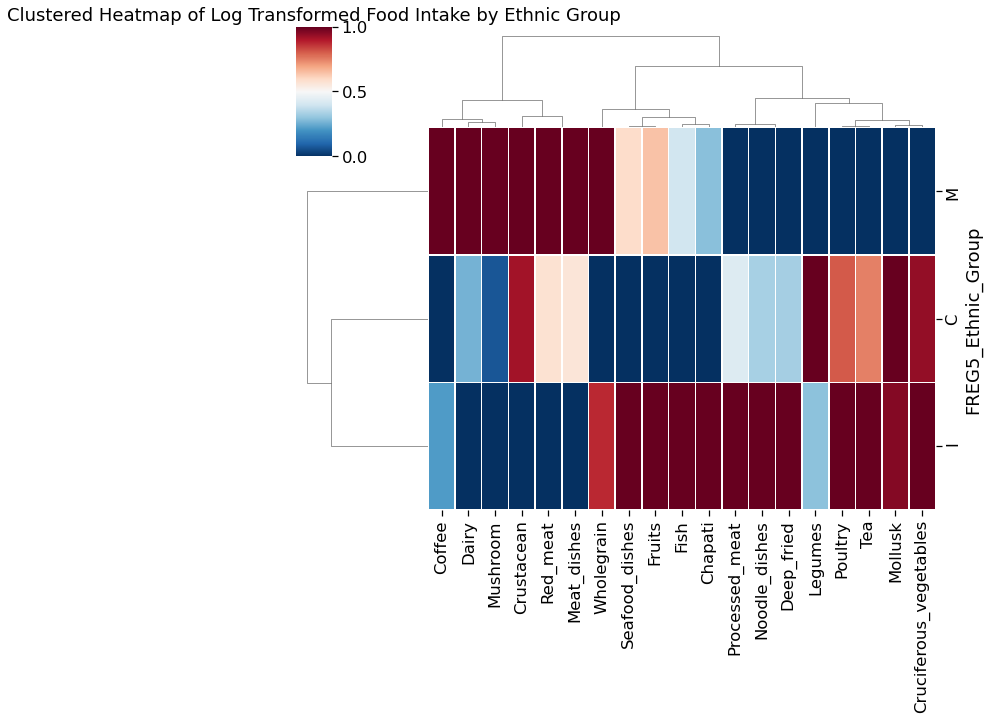

In [180]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(grouped_data)
scaled_data = pd.DataFrame(scaled_data, index=grouped_data.index, columns=grouped_data.columns)

# Clustering and heatmap visualization
Z = linkage(scaled_data.transpose(), 'ward')

# Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=scaled_data.columns, leaf_rotation=90)
plt.title('Dendrogram of Food Groups - Log Transformed')
plt.xlabel('Food Groups')
plt.ylabel('Distance')
plt.show()

# Clustered heatmap
sns.clustermap(scaled_data, cmap='RdBu_r', fmt=".2f", linewidths=.5, method='ward', col_linkage=Z)
plt.title('Clustered Heatmap of Log Transformed Food Intake by Ethnic Group')
plt.show()


In [181]:
## violin plot

In [182]:

melted_data = pd.melt(filtered_data, id_vars=['FREG5_Ethnic_Group'], var_name='Food_Group', value_name='Intake')
melted_data

,FREG5_Ethnic_Group,Food_Group,Intake
0,C,Fish,0.78
1,M,Fish,0.27
2,M,Fish,0.14
3,C,Fish,0.80
4,I,Fish,0.00
...,...,...,...
10122,C,Tea,0.00
10123,M,Tea,0.00
10124,I,Tea,1.00
10125,M,Tea,0.71


In [282]:
ethnicity_colors = {
    "C": "#4A8CC3",
    "I": "#E37939",
    "M": "#8FBC89",
    "O": "#80796BFF"
}



melted_data['FREG5_Ethnic_Group'] = pd.Categorical(melted_data['FREG5_Ethnic_Group'], categories=['C', 'I', 'M'], ordered=True)
melted_data = melted_data.sort_values('FREG5_Ethnic_Group')


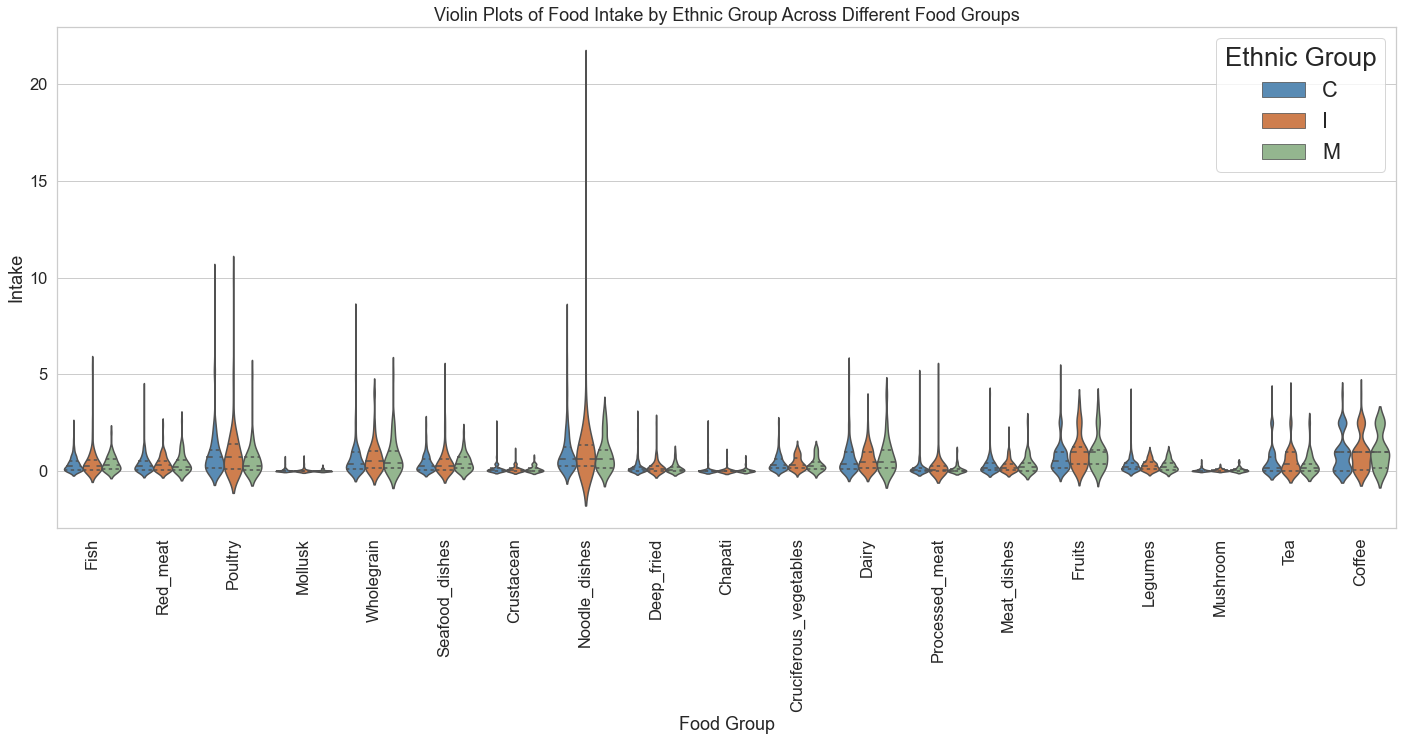

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the overall context for better font size and plot size
sns.set_context("notebook", font_scale=1.5)  # Increase font scale for better readability
plt.figure(figsize=(24, 12))  # Set a large figure size to accommodate all data

# Create the violin plot
ax = sns.violinplot(x='Food_Group', y='Intake', hue='FREG5_Ethnic_Group', data=melted_data,
               inner='quartile', scale='width', palette=ethnicity_colors)

plt.title('Violin Plots of Food Intake by Ethnic Group Across Different Food Groups')
plt.xticks(rotation=90)  # Rotate the x labels to 90 degrees for better visibility
plt.xlabel('Food Group')
plt.ylabel('Intake')
plt.legend(title='Ethnic Group', loc='upper right', fontsize='large', title_fontsize='x-large')

# Adjust the bottom margin to prevent labels from being cut off
plt.subplots_adjust(bottom=0.3)  # Adjust the bottom margin to give more space for labels

# Save the plot as a PNG file
#plt.savefig('figure/Food_Ethnic_violin.png', format='png', dpi=300, bbox_inches='tight')  # Save with tight bounding box to include all elements
plt.show()



In [284]:
# outliner in noodle dishes

In [285]:
def remove_outliers(df, lower_percentile=1, upper_percentile=99):
    for food_group in df['Food_Group'].unique():
        # Calculate lower and upper percentiles for each food group
        lower_bound = df[df['Food_Group'] == food_group]['Intake'].quantile(lower_percentile/100)
        upper_bound = df[df['Food_Group'] == food_group]['Intake'].quantile(upper_percentile/100)

        df = df[~((df['Food_Group'] == food_group) & ((df['Intake'] < lower_bound) | (df['Intake'] > upper_bound)))]
        
    return df


In [286]:
filtered_data2 = remove_outliers(melted_data)

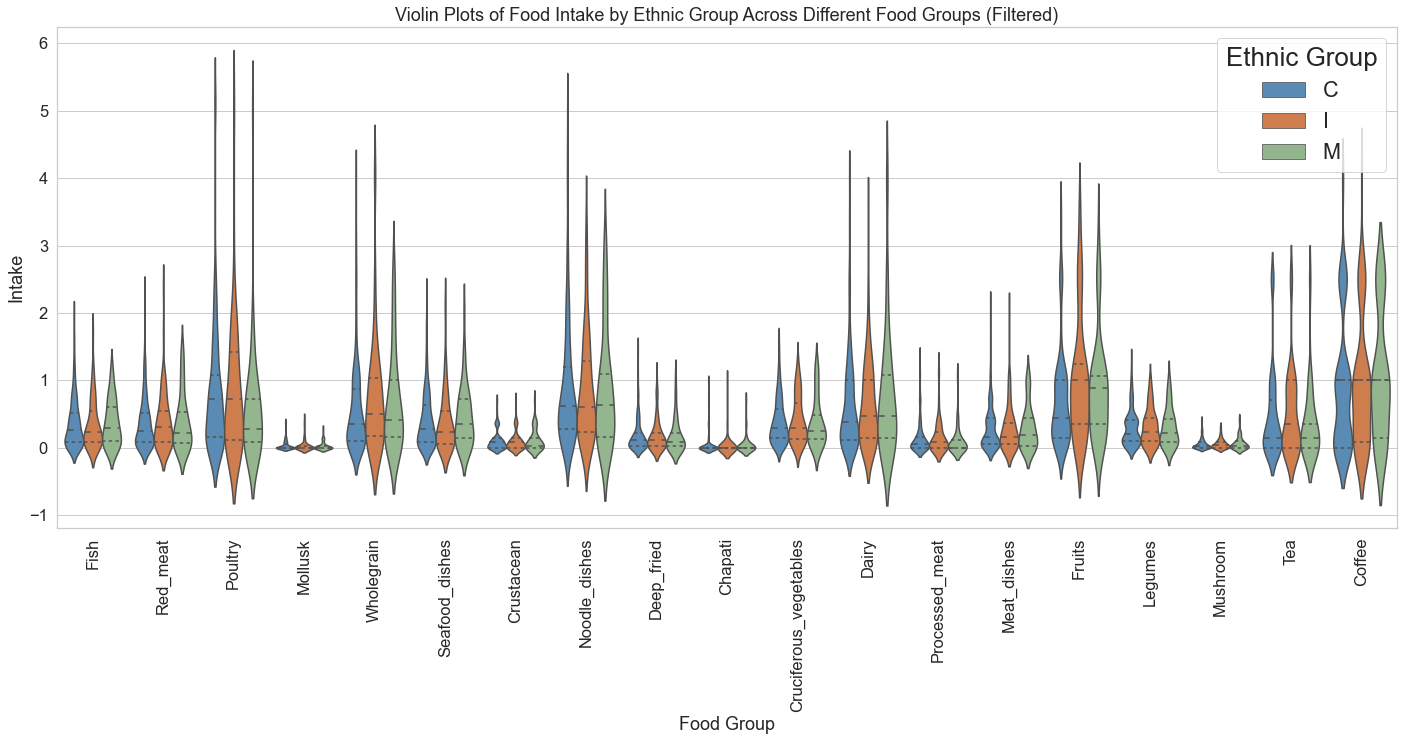

In [287]:
# Set the overall context for better font size and plot size
sns.set_context("notebook", font_scale=1.5)  # Increase font scale for better readability
plt.figure(figsize=(24, 12))  # Set a large figure size to accommodate all data

# Create the violin plot with the filtered data
ax = sns.violinplot(x='Food_Group', y='Intake', hue='FREG5_Ethnic_Group', data=filtered_data2,
               inner='quartile', scale='width', palette=ethnicity_colors)

plt.title('Violin Plots of Food Intake by Ethnic Group Across Different Food Groups (Filtered)')
plt.xticks(rotation=90)  # Rotate the x labels to 90 degrees for better visibility
plt.xlabel('Food Group')
plt.ylabel('Intake')
plt.legend(title='Ethnic Group', loc='upper right', fontsize='large', title_fontsize='x-large')

# Adjust the bottom margin to prevent labels from being cut off
plt.subplots_adjust(bottom=0.3)  # Adjust the bottom margin to give more space for labels

# Save the plot as a PNG file
#plt.savefig('figure/Food_Ethnic_violin_filtered.png', format='png', dpi=300, bbox_inches='tight')  # Save with tight bounding box to include all elements
plt.show()


In [288]:
# box plot

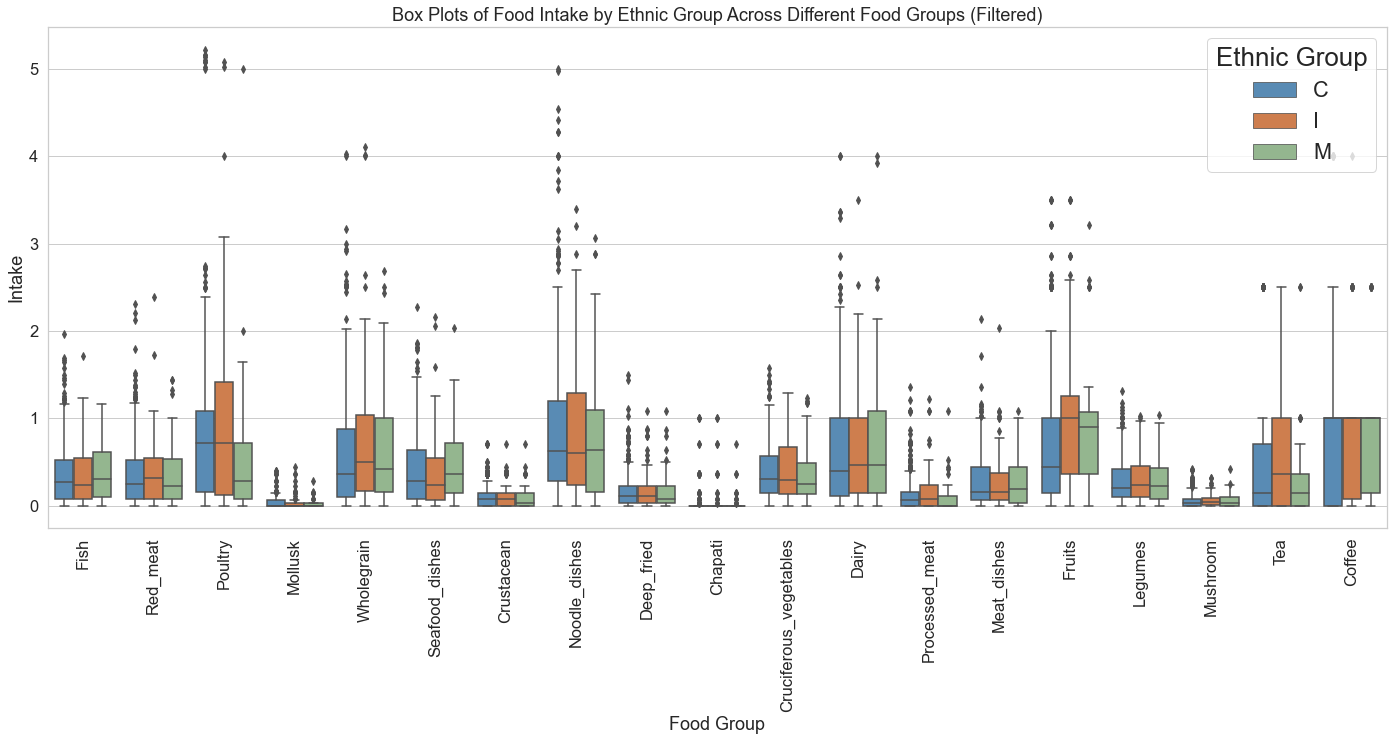

In [289]:
# Set the overall context for better font size and plot size
sns.set_context("notebook", font_scale=1.5)  # Increase font scale for better readability
plt.figure(figsize=(24, 12))  # Set a large figure size to accommodate all data

# Create the boxplot with the filtered data
ax = sns.boxplot(x='Food_Group', y='Intake', hue='FREG5_Ethnic_Group', data=filtered_data2,
                 palette=ethnicity_colors)

plt.title('Box Plots of Food Intake by Ethnic Group Across Different Food Groups (Filtered)')
plt.xticks(rotation=90)  # Rotate the x labels to 90 degrees for better visibility
plt.xlabel('Food Group')
plt.ylabel('Intake')
plt.legend(title='Ethnic Group', loc='upper right', fontsize='large', title_fontsize='x-large')

# Adjust the bottom margin to prevent labels from being cut off
plt.subplots_adjust(bottom=0.3)  # Adjust the bottom margin to give more space for labels

# Save the plot as a PNG file
#plt.savefig('figure/Food_Ethnic_box_filtered.png', format='png', dpi=300, bbox_inches='tight')  # Save with tight bounding box to include all elements
plt.show()



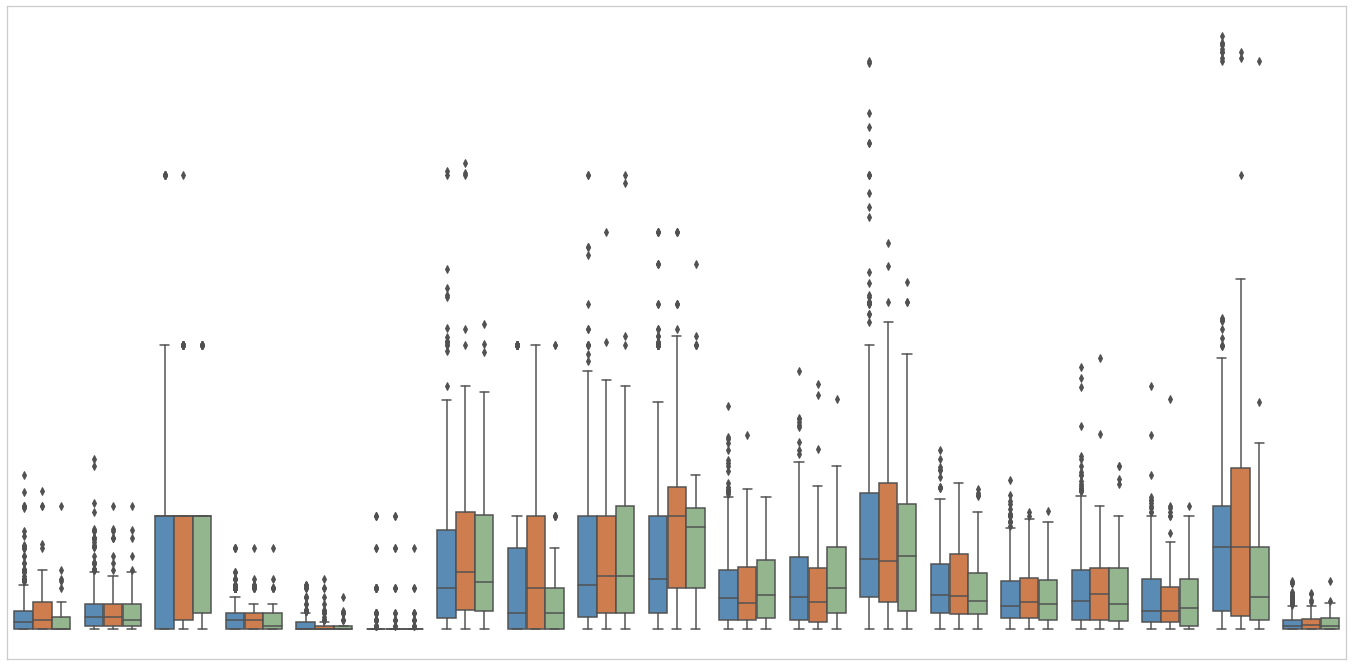

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set context for better readability
sns.set_context("notebook", font_scale=1.5)

# Define the figure size
plt.figure(figsize=(24, 12))

# Specify the order of categories as per your requirement
x_labels = ["Processed_meat", "Deep_fried", "Coffee", "Crustacean", "Mollusk", "Chapati", "Wholegrain",
            "Tea", "Dairy", "Fruits", "Fish", "Seafood_dishes", "Noodle_dishes", "Cruciferous_vegetables", 
            "Legumes", "Red_meat", "Meat_dishes", "Poultry", "Mushroom"]

# Create the boxplot with specified order
ax = sns.boxplot(x='Food_Group', y='Intake', hue='FREG5_Ethnic_Group', data=filtered_data2,
                 palette=ethnicity_colors, order=x_labels)

# Customize the plot with title, labels, and rotation for x-ticks
#plt.title('Box Plots of Food Intake by Ethnic Group Across Different Food Groups (Filtered)')
#plt.xticks(rotation=70)
#plt.xlabel('Food Group')
#plt.ylabel('Intake')
#plt.legend(title='Ethnic Group', loc='upper right', fontsize='large', title_fontsize='x-large')

#ax.grid(False)
# Adjust the bottom margin to prevent label cutoff
#plt.subplots_adjust(bottom=0.3)

# Remove axis labels
ax.set(xlabel=None, ylabel=None)

# Remove x and y ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove the legend if you do not need it
ax.legend_.remove()

# Save the plot
plt.savefig('figure/Food_Ethnic_box_top.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# heatmap 

In [106]:
butyrate_data = pd.read_excel("data/butyrate_pick.xlsx", index_col=0)
food_data = pd.read_csv('data/Summarized_Food_Categories_Only.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

In [107]:
common_indices = butyrate_data.index.intersection(food_data.index)
butyrate_data = butyrate_data.loc[common_indices]
food_data = food_data.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [108]:
# Convert data to numeric and handle non-numeric entries
butyrate_data = butyrate_data.apply(pd.to_numeric, errors='coerce')
food_data = food_data.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')


In [116]:
def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_butyrate_data2 = adjust_for_covariates(butyrate_data, participants_data[['BMI', 'FREG8_Age', 'FREG7_Gender']], categorical_vars=['FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data, participants_data[['BMI', 'FREG8_Age', 'FREG7_Gender']], categorical_vars=['FREG7_Gender'])


In [117]:
correlations_butyrate2 = pd.DataFrame(index=adjusted_butyrate_data2.columns, columns=adjusted_food_spear.columns)
p_values_butyrate2 = pd.DataFrame(index=adjusted_butyrate_data2.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_butyrate2 = correlations_butyrate2.astype(float)  # Convert to float
p_values_butyrate2 = p_values_butyrate2.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_butyrate2.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [118]:
for microbe in adjusted_butyrate_data2.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_butyrate_data2[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_butyrate_data2[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_butyrate2.loc[microbe, nutrient] = corr
            p_values_butyrate2.loc[microbe, nutrient] = pval
        else:
            correlations_butyrate2.loc[microbe, nutrient] = np.nan
            p_values_butyrate2.loc[microbe, nutrient] = np.nan



In [119]:
p_flat = p_values_butyrate2.values.flatten()
reject, corrected_pvals_butyrate2, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_butyrate2 = pd.DataFrame(reject.reshape(p_values_butyrate2.shape), index=adjusted_butyrate_data2.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_butyrate2.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 0
filtered_species_butyrate2 = correlations_butyrate2.loc[significant_species.index[significant_species]]


<Figure size 1440x2880 with 0 Axes>

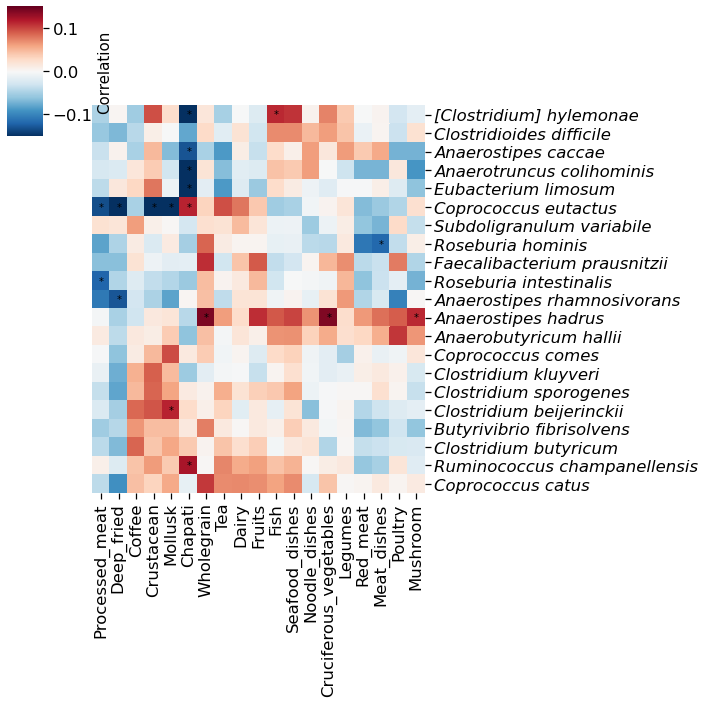

In [201]:
filtered_significance_matrix_butyrate2 = significant_matrix_butyrate2.loc[filtered_species_butyrate2.index, filtered_species_butyrate2.columns]
clipped_correlations_butyrate2 = np.clip(filtered_species_butyrate2, -0.2, 0.2)


plt.figure(figsize=(20, 40))
ax = sns.clustermap(clipped_correlations_butyrate2, method='ward', cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.15, vmax=0.15, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_butyrate2):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
      



#for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spear):
    #if significant:
        #ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)
      
#plt.title('Adjusted Spearman Correlations between Microbial Species and Nutrition')
#plt.xlabel('Food Gr')
#plt.ylabel('correlation')

plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)
#plt.rc('figure', titlesize=)
plt.show()

#plt.savefig('Repeat_Predictnutrigroup_only.png', dpi=300)  

#plt.close()

In [151]:
#combine?

In [196]:

x_labels = ["Processed_meat", "Deep_fried", "Coffee", "Crustacean", "Mollusk","Chapati", "Wholegrain", 
            "Tea", "Dairy", "Fruits","Fish", "Seafood_dishes", "Noodle_dishes", "Cruciferous_vegetables", "Legumes", "Red_meat", 
             "Meat_dishes","Poultry", "Mushroom"]

y_labels = ["[Clostridium] hylemonae", "Clostridioides difficile", "Anaerostipes caccae", 
            "Anaerotruncus colihominis", "Eubacterium limosum", "Coprococcus eutactus", 
            "Subdoligranulum variabile", "Roseburia hominis", "Faecalibacterium prausnitzii", 
            "Roseburia intestinalis", "Anaerostipes rhamnosivorans", "Anaerostipes hadrus", 
            "Anaerobutyricum hallii", "Coprococcus comes", "Clostridium kluyveri", "Clostridium sporogenes", 
            "Clostridium beijerinckii", "Butyrivibrio fibrisolvens", "Clostridium butyricum", 
            "Ruminococcus champanellensis", "Coprococcus catus"]



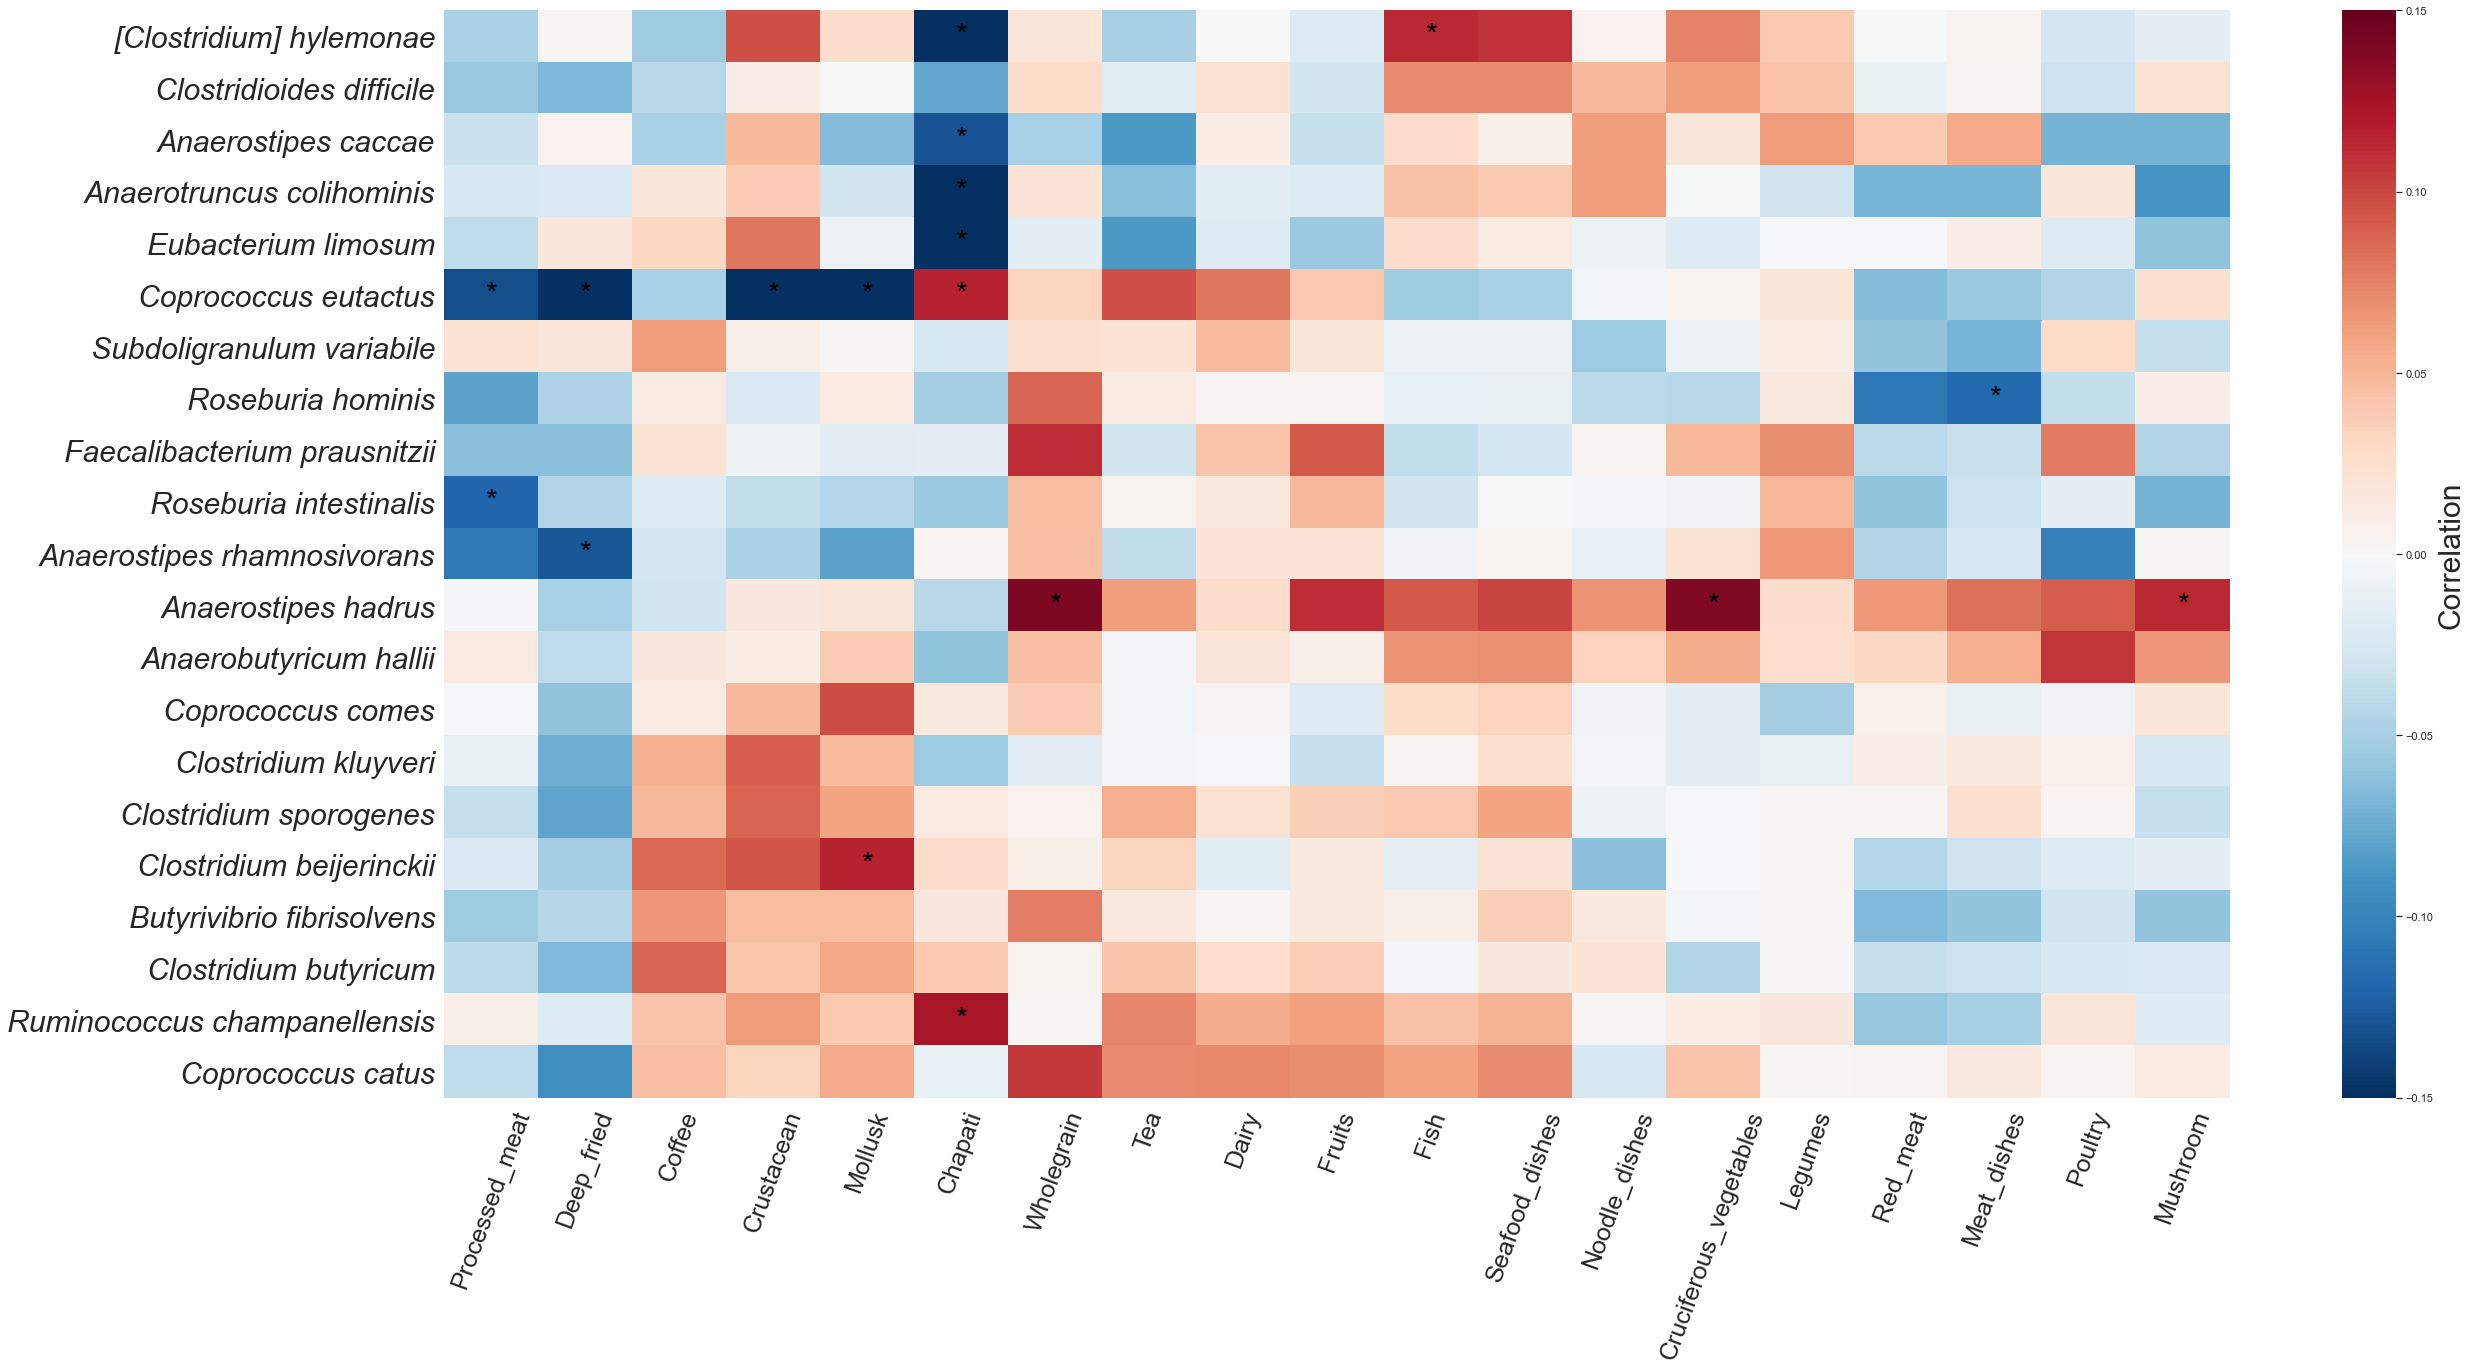

In [241]:


# Assuming 'significant_matrix_butyrate2' and 'correlations_butyrate2' are precomputed as shown above

# Set the figure size
plt.figure(figsize=(40, 20))

# Reorder the columns and rows based on your specified order
data_reordered = clipped_correlations_butyrate2.loc[y_labels, x_labels]
significance_reordered = filtered_significance_matrix_butyrate2.loc[y_labels, x_labels]

# Create the heatmap
ax = sns.heatmap(data_reordered, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.15, vmax=0.15)

# Plot stars for significant correlations
for (i, j), significant in np.ndenumerate(significance_reordered):
    if significant:
        ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=30)

# Customize ticks and labels
plt.xticks(np.arange(len(x_labels)) + 0.5, x_labels, rotation=70, fontsize=25)
plt.yticks(np.arange(len(y_labels)) + 0.5, y_labels, rotation=0, fontstyle='italic', fontsize=30)

# Additional aesthetic settings
plt.rc('font', size=15)
plt.rc('axes', labelsize=30)
plt.rc('axes', titlesize=30)

# Display the plot
plt.savefig('figure/Correlations_bottom.png', format='png', dpi=300, bbox_inches='tight')
#plt.show()


In [ ]:
#combine

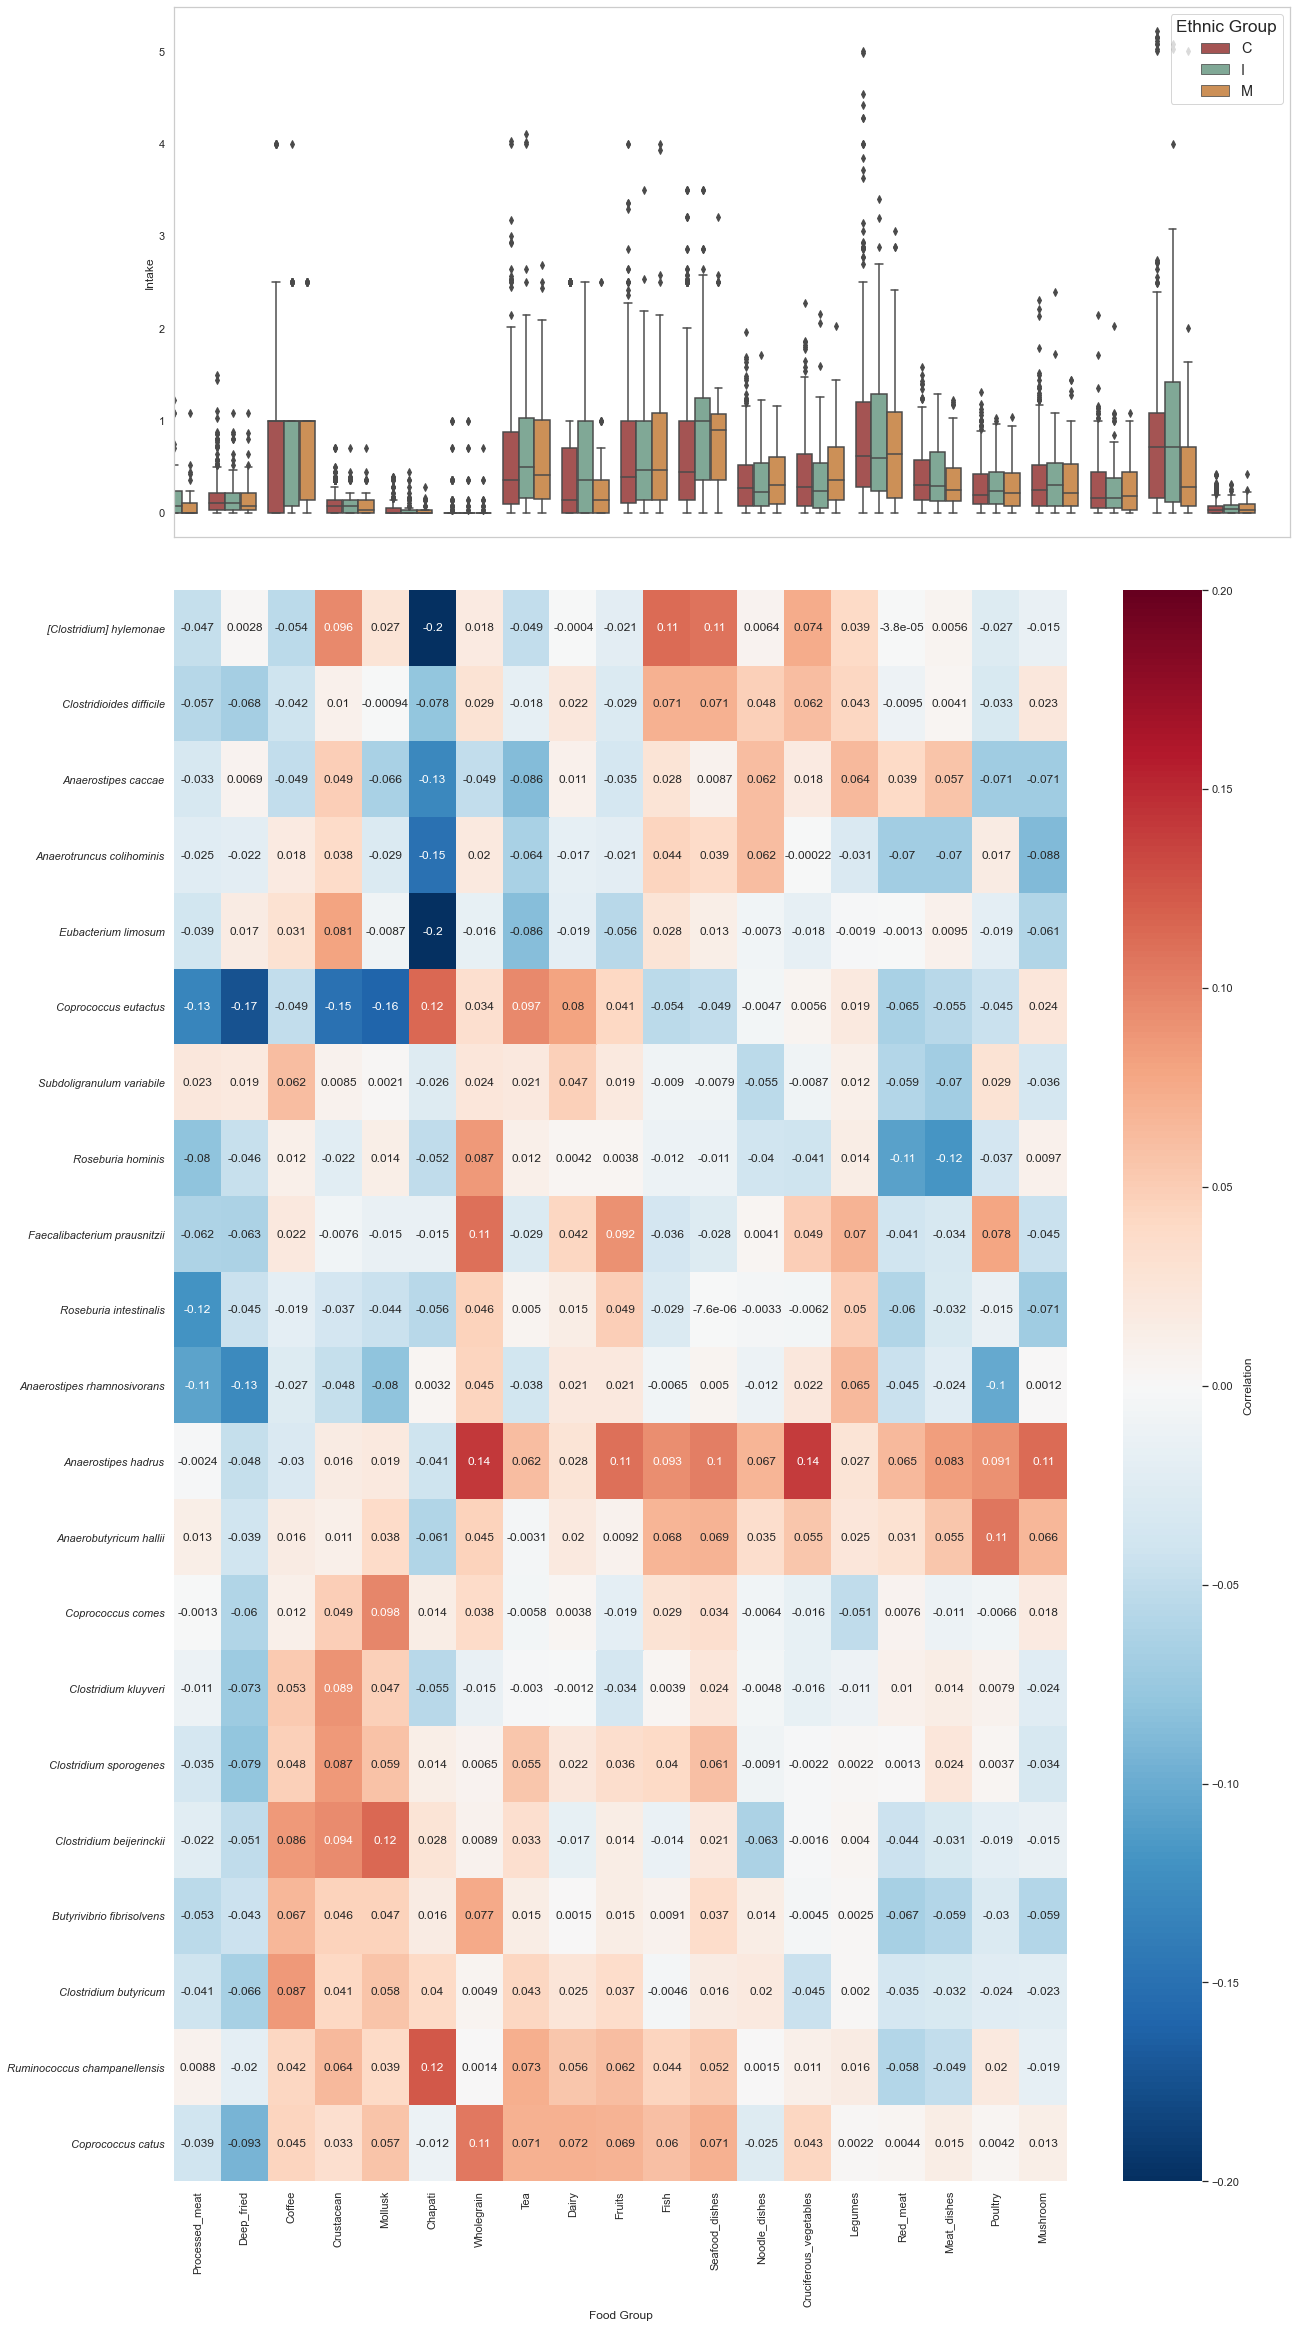

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")  # Set the style but will turn off grid later for boxplot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 40), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Boxplot
box = sns.boxplot(x='Food_Group', y='Intake', hue='FREG5_Ethnic_Group', data=filtered_data2,
                  palette=ethnicity_colors, order=x_labels, ax=ax1)
ax1.set_xlabel('')  # Remove x-axis label
ax1.set_ylabel('Intake')
ax1.legend(title='Ethnic Group', loc='upper right', fontsize='large', title_fontsize='x-large')
ax1.grid(False)  # Turn off the grid for the boxplot

# Match the number of ticks and their positions
ax1.set_xticks(np.arange(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=90)

# Heatmap
sns.heatmap(clipped_correlations_butyrate3, cmap="RdBu_r", annot=True, cbar_kws={'label': 'Correlation'},
            vmin=-0.2, vmax=0.2, ax=ax2)
ax2.set_xticks(np.arange(len(x_labels)) + 0.5)  # Center the x-tick labels
ax2.set_xticklabels(x_labels, rotation=90)
ax2.set_yticklabels(y_labels, rotation=0, fontstyle='italic')
ax2.set_xlabel('Food Group')

plt.subplots_adjust(hspace=0.05)  # Minimize space between the plots

#plt.savefig('figure/Combined_Food_Intake_Correlations.png', format='png', dpi=300, bbox_inches='tight')
plt.show()
